# ZeroER++ — full-data benchmarks (phase 2)

Takes each dataset's tuning Pareto front and re-evaluates it on the **full data**, into sibling `<dataset>_full` studies in the same `outputs/optuna.db`. Run `hyperparameter-tuning.ipynb` first.

## Setup

Generic runners/views in `utils`; the objective + its knobs are declared below and **must match the tuning run** (enqueued configs replay through the same distributions).

In [1]:
from pyjedai_module import ZeroEREstimator
from utils import (DATASETS, DEFAULT_TUNE_FRACTION, load_data,
                   precision_recall_f1, blocking_recall,   # objective helpers
                   retrain_all, export, show_results)

/opt/conda/envs/chinochat/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.1) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/opt/conda/envs/chinochat/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-01 10:09:14,689	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Search space

Same `SPACE`/`SEED` as tuning; no budget needed — phase 2 only enqueues the existing front.

In [2]:
SEED = 0
SPACE = {                                     # the knobs; each key is a flat ZeroEREstimator arg
    # embeddings branch — PLM blocking. Static vectorizers (word2vec/glove/...) excluded: not LMs.
    "vectorizer": ["sminilm", "smpnet", "st5", "sdistilroberta",   # sentence-transformer PLMs
                   "bert", "distilbert", "roberta", "xlnet", "albert"],  # token PLMs
    "top_k": (1, 10),                         # neighbours kept per entity
    "similarity_distance": ["cosine", "euclidean"],
    # standard branch — syntactic blocking + cleaning
    "smoothing_factor": (1.0, 1.5),           # BlockPurging threshold
    "block_filtering_ratio": (0.5, 0.95),     # BlockFiltering keep-ratio
    "weighting_scheme": ["CBS", "ECBS", "JS", "EJS", "X2"],  # WeightedEdgePruning
    # matcher (searched in both branches)
    "c_bay": (1e-3, 3e-1),                    # ZeroER EM regularisation (log-float)
}

## Objective

The per-experiment trial — declared here, not in `utils`, so a new experiment is just a copy-and-tweak of this cell. It returns `(F1, candset, pair_completeness)` and carries its own `directions`; `make_objective` binds it to `SPACE`/`SEED` for the runners.

In [3]:
class TuningObjective:
    """Multi-objective trial: (max F1, min surviving block pairs, max pair completeness).

    One ``Data`` is loaded per instance and reused across trials; ``get_params``
    *is* the search space (keys map one-to-one onto the ZeroEREstimator ctor).
    """
    directions = ["maximize", "minimize", "maximize"]   # F1 up, block pairs down, PC up

    def __init__(self, dataset, space, seed=0, partition=True):
        self.space = space
        self.source_trial = None              # set by retrain_full to stamp each full trial
        self.data = load_data(dataset, partition=partition, seed=seed)
        self.attributes = DATASETS[dataset]["attributes"]
        frac = DATASETS[dataset].get("tune_fraction", DEFAULT_TUNE_FRACTION)
        scope = f"partition (frac={frac})" if partition else "full data"
        print(f"    {scope}: {self.data.num_of_entities_1}+{self.data.num_of_entities_2}"
              f" entities, {len(self.data.ground_truth)} matches", flush=True)

    def get_params(self, trial):
        # conditional: the blocker is itself a knob; each branch exposes only its
        # own stage params; c_bay (the matcher) is searched in both branches.
        s = self.space
        blocker = trial.suggest_categorical("blocker", ["embeddings", "standard"])
        params = dict(blocker=blocker,
                      c_bay=trial.suggest_float("c_bay", *s["c_bay"], log=True))
        if blocker == "embeddings":
            params.update(
                vectorizer=trial.suggest_categorical("vectorizer", s["vectorizer"]),
                top_k=trial.suggest_int("top_k", *s["top_k"]),
                similarity_distance=trial.suggest_categorical("similarity_distance", s["similarity_distance"]),
            )
        else:
            params.update(
                smoothing_factor=trial.suggest_float("smoothing_factor", *s["smoothing_factor"]),
                block_filtering_ratio=trial.suggest_float("block_filtering_ratio", *s["block_filtering_ratio"]),
                weighting_scheme=trial.suggest_categorical("weighting_scheme", s["weighting_scheme"]),
            )
        return params

    def __call__(self, trial):
        est = ZeroEREstimator(attributes=self.attributes, **self.get_params(trial))
        graph = est.fit_predict(self.data)
        _, _, f1 = precision_recall_f1(graph, self.data)
        pair_completeness = blocking_recall(est.blocks, self.data)   # gold kept by the blocker
        trial.set_user_attr("candset_size", est.candset_size)
        trial.set_user_attr("blocking_seconds", round(est.blocking_seconds, 3))
        trial.set_user_attr("em_seconds", round(est.matcher.em_time, 3))
        if self.source_trial is not None:
            trial.set_user_attr("source_trial", self.source_trial)
        return f1, est.candset_size, pair_completeness


def make_objective(dataset, partition=True):                 # factory the runners call per dataset
    return TuningObjective(dataset, SPACE, SEED, partition=partition)

## Run phase 2 — retrain each front on the full data

Resumable: configs already retrained (stamped `source_trial`) are skipped.

In [4]:
retrain_all(make_objective, seed=SEED)


=== retraining fodors_zagats front on full data ===
    full data: 533+331 entities, 112 matches


[I 2026-06-01 10:09:24,170] A new study created in RDB with name: fodors_zagats_full
/opt/conda/envs/chinochat/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
  0%|          | 0/40 [00:00<?, ?it/s]/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/module.py:440: RuntimeWarning: some failed to converge after 5 iterations
  kappas = newton(bay_coeff_equ, x0=x0, x1=x1, maxiter=5, tol=1)
/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/module.py:440: RuntimeWarning: RMS of 4.55619e+23 reached
  kappas = newton(bay_coeff_equ, x0=x0, x1=x1, maxiter=5, tol=1)
/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/module.py:440: RuntimeWarning: RMS of 1.78024e+31 reached
  kappas = newton(bay_coeff_equ, x0=x

  full: F1=0.7761 candset=182 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.11395032674446523, 'smoothing_factor': 1.0305874260352816, 'block_filtering_ratio': 0.8289005337914328, 'weighting_scheme': 'CBS'}
  full: F1=0.9558 candset=194 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.06175906143017537, 'smoothing_factor': 1.0337032370132886, 'block_filtering_ratio': 0.7221472631514566, 'weighting_scheme': 'ECBS'}
  full: F1=0.9600 candset=284 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.09437940898537311, 'smoothing_factor': 1.016858724839636, 'block_filtering_ratio': 0.818282740752018, 'weighting_scheme': 'X2'}
  full: F1=0.9636 candset=289 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.13439349878392615, 'smoothing_factor': 1.0173358140104256, 'block_filtering_ratio': 0.7852226560185827, 'weighting_scheme': 'X2'}
  full: F1=0.6477 candset=141 PC=1.0000 {'blocker': 'standard', 'c_bay': 0.062056032283172025, 'smoothing_factor': 1.0151007168264117, 'block_filtering_ratio': 0.720533855082105, 

[I 2026-06-01 10:09:53,359] A new study created in RDB with name: dblp_acm_full
/opt/conda/envs/chinochat/lib/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
 48%|████▊     | 19/40 [00:00<00:00, 216.63it/s]
[I 2026-06-01 10:14:28,292] Trial 0 finished with values: [0.9708737864077669, 4588.0, 0.9955035971223022] and parameters: {'blocker': 'embeddings', 'c_bay': 0.007867226146268723, 'vectorizer': 'st5', 'top_k': 2, 'similarity_distance': 'cosine'}.
  0%|          | 0/40 [00:00<?, ?it/s]/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/module.py:75: RuntimeWarning: invalid value encountered in log
  return np.exp(-(np.log(a / (b + DEL) + b / (a + DEL) + 2) + u / (a + b + DEL)))
/home/mda4172@tmme/s3_personal_directory/pyJedAI/ZeroER/module.py:440: RuntimeWarning:

  full: F1=0.9709 candset=4588 PC=0.9955 {'blocker': 'embeddings', 'c_bay': 0.007867226146268723, 'vectorizer': 'st5', 'top_k': 2, 'similarity_distance': 'cosine'}
  full: F1=0.9305 candset=2294 PC=0.9861 {'blocker': 'embeddings', 'c_bay': 0.0055113428604880825, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'cosine'}

=== retraining dblp_scholar front on full data ===
    full data: 2616+64263 entities, 5347 matches


...

  full: F1=0.6537 candset=1431185 PC=0.9987 {'blocker': 'standard', 'c_bay': 0.0010324380974467869, 'smoothing_factor': 1.2783363780105759, 'block_filtering_ratio': 0.5415641500548766, 'weighting_scheme': 'X2'}
  full: F1=0.4445 candset=64263 PC=0.9587 {'blocker': 'embeddings', 'c_bay': 0.004342708044636484, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'cosine'}
  full: F1=0.5232 candset=712951 PC=0.9983 {'blocker': 'standard', 'c_bay': 0.01217640874215835, 'smoothing_factor': 1.4835133227364306, 'block_filtering_ratio': 0.6422214437859184, 'weighting_scheme': 'CBS'}
  full: F1=0.5444 candset=576918 PC=0.9979 {'blocker': 'standard', 'c_bay': 0.012922242412813024, 'smoothing_factor': 1.2719344697766684, 'block_filtering_ratio': 0.6200753933719224, 'weighting_scheme': 'CBS'}
  full: F1=0.7488 candset=341185 PC=0.9972 {'blocker': 'standard', 'c_bay': 0.01708784851475899, 'smoothing_factor': 1.2208666089361322, 'block_filtering_ratio': 0.573282932972805, 'weighting_scheme': 'CBS

[I 2026-06-01 12:31:43,105] A new study created in RDB with name: abt_buy_full
 40%|████      | 16/40 [00:01<00:02,  8.42it/s]
[I 2026-06-01 12:32:01,626] Trial 0 finished with values: [0.023458350891979212, 101496.0, 0.9945305378304466] and parameters: {'blocker': 'standard', 'c_bay': 0.0017088424969157376, 'smoothing_factor': 1.2879732477780896, 'block_filtering_ratio': 0.9181832889092962, 'weighting_scheme': 'EJS'}.
/opt/conda/envs/chinochat/lib/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
 32%|███▎      | 13/40 [00:00<00:00, 174.39it/s]
[I 2026-06-01 12:35:37,225] Trial 1 finished with values: [0.18926134678137052, 7644.0, 0.959890610756609] and parameters: {'blocker': 'embeddings', 'c_bay': 0.003293446296327548, 'vectorizer': 'st5', 'top_k': 7, 'similarity_dist

  full: F1=0.0235 candset=101496 PC=0.9945 {'blocker': 'standard', 'c_bay': 0.0017088424969157376, 'smoothing_factor': 1.2879732477780896, 'block_filtering_ratio': 0.9181832889092962, 'weighting_scheme': 'EJS'}
  full: F1=0.3512 candset=1092 PC=0.7393 {'blocker': 'embeddings', 'c_bay': 0.0023563821709718705, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'euclidean'}
  full: F1=0.3512 candset=1092 PC=0.7393 {'blocker': 'embeddings', 'c_bay': 0.0016040106934220829, 'vectorizer': 'st5', 'top_k': 1, 'similarity_distance': 'euclidean'}
  full: F1=0.3212 candset=2184 PC=0.8587 {'blocker': 'embeddings', 'c_bay': 0.002362837633219082, 'vectorizer': 'st5', 'top_k': 2, 'similarity_distance': 'euclidean'}
  full: F1=0.2899 candset=3276 PC=0.9034 {'blocker': 'embeddings', 'c_bay': 0.0010573734835665717, 'vectorizer': 'st5', 'top_k': 3, 'similarity_distance': 'euclidean'}
  full: F1=0.2899 candset=3276 PC=0.9034 {'blocker': 'embeddings', 'c_bay': 0.0010217737928983983, 'vectorizer': 'st5'

[I 2026-06-01 12:36:51,514] A new study created in RDB with name: amazon_googleproducts_full
 45%|████▌     | 18/40 [00:12<00:14,  1.48it/s]
[I 2026-06-01 12:58:50,660] Trial 0 finished with values: [0.113125, 615566.0, 0.9915384615384616] and parameters: {'blocker': 'standard', 'c_bay': 0.05347084697914042, 'smoothing_factor': 1.030112735814635, 'block_filtering_ratio': 0.8000450219505504, 'weighting_scheme': 'CBS'}.
/opt/conda/envs/chinochat/lib/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
 42%|████▎     | 17/40 [00:00<00:00, 275.75it/s]
[I 2026-06-01 13:00:03,405] Trial 1 finished with values: [0.19525959367945822, 3226.0, 0.6523076923076923] and parameters: {'blocker': 'embeddings', 'c_bay': 0.01921829318152302, 'vectorizer': 'sminilm', 'top_k': 1, 'similarity_d

  full: F1=0.1131 candset=615566 PC=0.9915 {'blocker': 'standard', 'c_bay': 0.05347084697914042, 'smoothing_factor': 1.030112735814635, 'block_filtering_ratio': 0.8000450219505504, 'weighting_scheme': 'CBS'}
  full: F1=0.1953 candset=3226 PC=0.6523 {'blocker': 'embeddings', 'c_bay': 0.01921829318152302, 'vectorizer': 'sminilm', 'top_k': 1, 'similarity_distance': 'cosine'}
  full: F1=0.1935 candset=9678 PC=0.8492 {'blocker': 'embeddings', 'c_bay': 0.0015439574540934541, 'vectorizer': 'st5', 'top_k': 3, 'similarity_distance': 'cosine'}
  full: F1=0.1849 candset=12904 PC=0.8854 {'blocker': 'embeddings', 'c_bay': 0.0011947821619647438, 'vectorizer': 'st5', 'top_k': 4, 'similarity_distance': 'euclidean'}
  full: F1=0.1935 candset=9678 PC=0.8492 {'blocker': 'embeddings', 'c_bay': 0.0010625584770212256, 'vectorizer': 'st5', 'top_k': 3, 'similarity_distance': 'cosine'}
  full: F1=0.1935 candset=9678 PC=0.8492 {'blocker': 'embeddings', 'c_bay': 0.0010320752491353171, 'vectorizer': 'st5', 'top_k

## Results

This notebook produces the `full` fronts; the `partition` fronts are shown too when present in `optuna.db`.

=== partition: 55 Pareto-optimal configs across 5 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,blocker,vectorizer,top_k,similarity_distance,smoothing_factor,block_filtering_ratio,weighting_scheme,c_bay,blocking_seconds,em_seconds,source_trial
0,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00236,0.009,0.064,None
1,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00160,0.009,0.065,None
2,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,cosine,NaN,NaN,None,0.00163,0.010,0.064,None
3,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00236,0.011,0.064,None
4,abt_buy,partition,0.3832,329,0.8419,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00255,0.009,0.064,None
5,abt_buy,partition,0.3467,658,0.9210,embeddings,st5,2.0,euclidean,NaN,NaN,None,0.00236,0.009,0.068,None
6,abt_buy,partition,0.3467,658,0.9210,embeddings,st5,2.0,euclidean,NaN,NaN,None,0.00143,0.009,0.069,None
7,abt_buy,partition,0.3040,987,0.9635,embeddings,st5,3.0,euclidean,NaN,NaN,None,0.00106,0.009,0.072,None
8,abt_buy,partition,0.3040,987,0.9635,embeddings,st5,3.0,euclidean,NaN,NaN,None,0.00102,0.010,0.071,None
9,abt_buy,partition,0.2606,1316,0.9696,embeddings,st5,4.0,cosine,NaN,NaN,None,0.00104,0.010,0.077,None


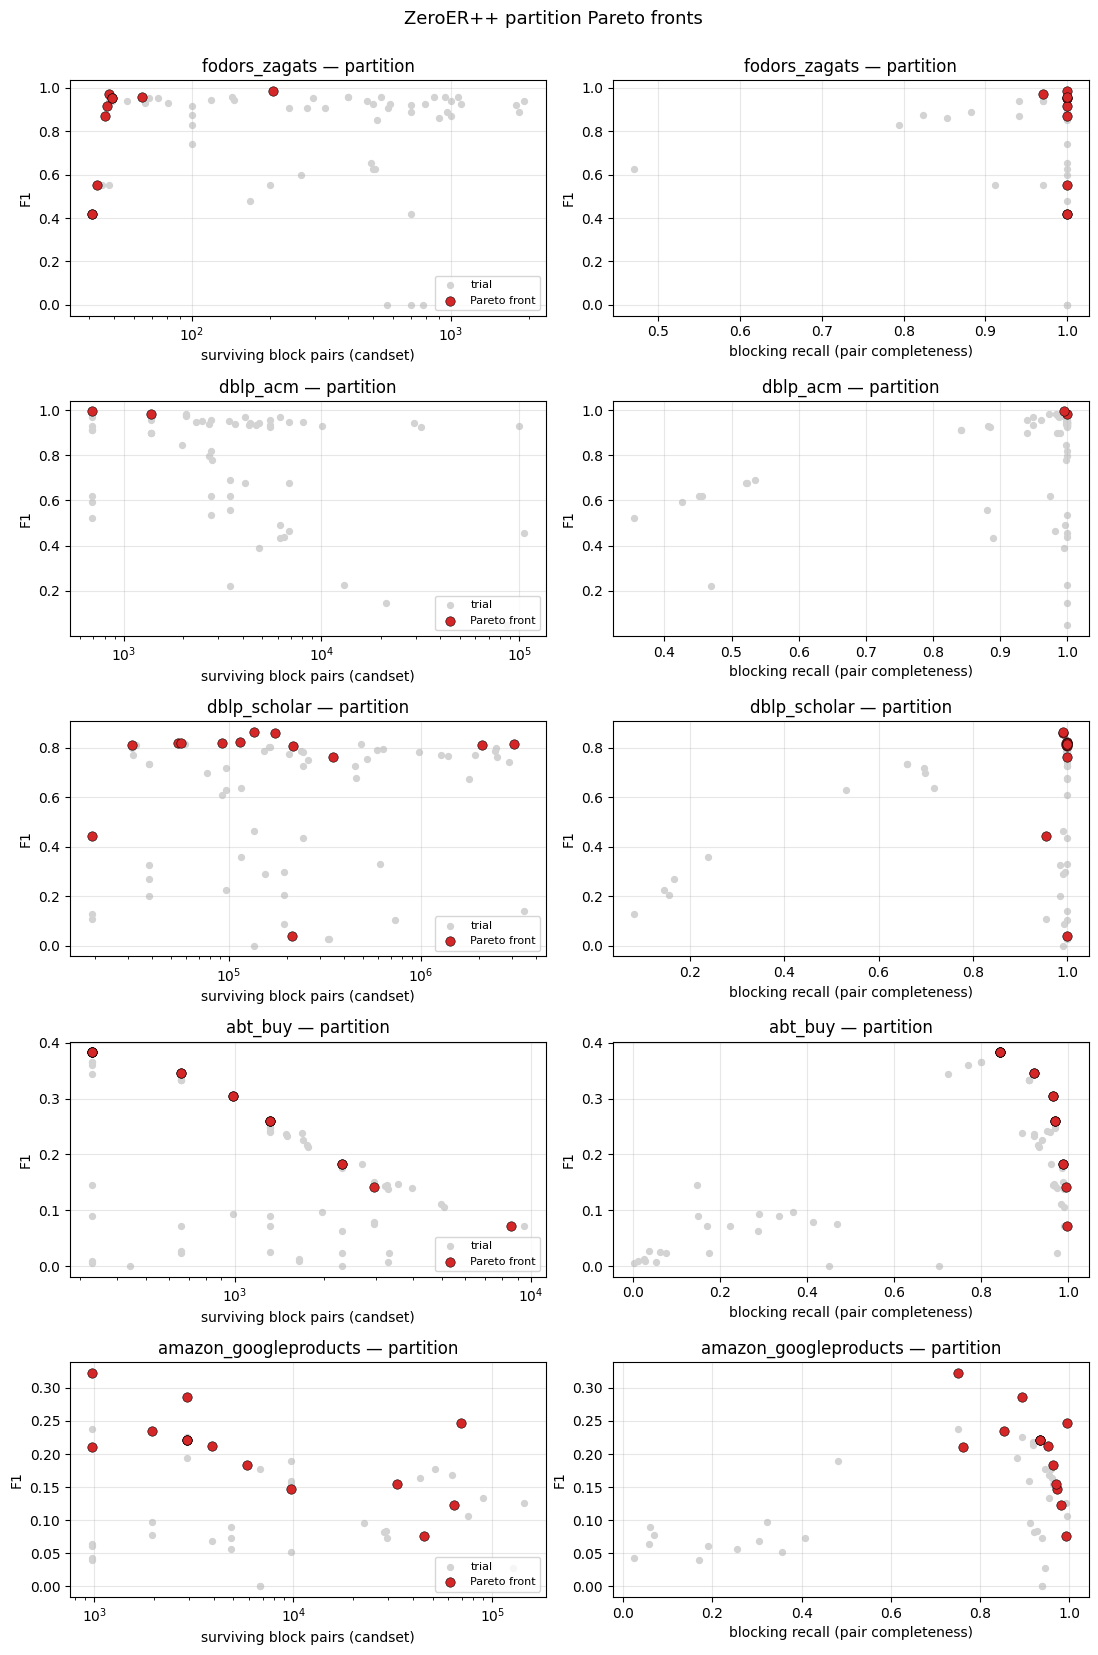

=== full: 45 Pareto-optimal configs across 5 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,blocker,vectorizer,top_k,similarity_distance,smoothing_factor,block_filtering_ratio,weighting_scheme,c_bay,blocking_seconds,em_seconds,source_trial
0,abt_buy,full,0.3512,1092,0.7393,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00236,0.120,0.076,38
1,abt_buy,full,0.3512,1092,0.7393,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00160,0.061,0.074,39
2,abt_buy,full,0.3512,1092,0.7393,embeddings,st5,1.0,cosine,NaN,NaN,None,0.00163,0.042,0.075,45
3,abt_buy,full,0.3512,1092,0.7393,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00236,0.063,0.076,50
4,abt_buy,full,0.3512,1092,0.7393,embeddings,st5,1.0,euclidean,NaN,NaN,None,0.00255,0.062,0.074,59
5,abt_buy,full,0.3212,2184,0.8587,embeddings,st5,2.0,euclidean,NaN,NaN,None,0.00236,0.070,0.094,40
6,abt_buy,full,0.3212,2184,0.8587,embeddings,st5,2.0,euclidean,NaN,NaN,None,0.00143,0.070,0.091,46
7,abt_buy,full,0.2899,3276,0.9034,embeddings,st5,3.0,euclidean,NaN,NaN,None,0.00106,0.070,0.105,41
8,abt_buy,full,0.2899,3276,0.9034,embeddings,st5,3.0,euclidean,NaN,NaN,None,0.00102,0.071,0.104,42
9,abt_buy,full,0.2595,4368,0.9325,embeddings,st5,4.0,cosine,NaN,NaN,None,0.00104,0.072,0.119,43


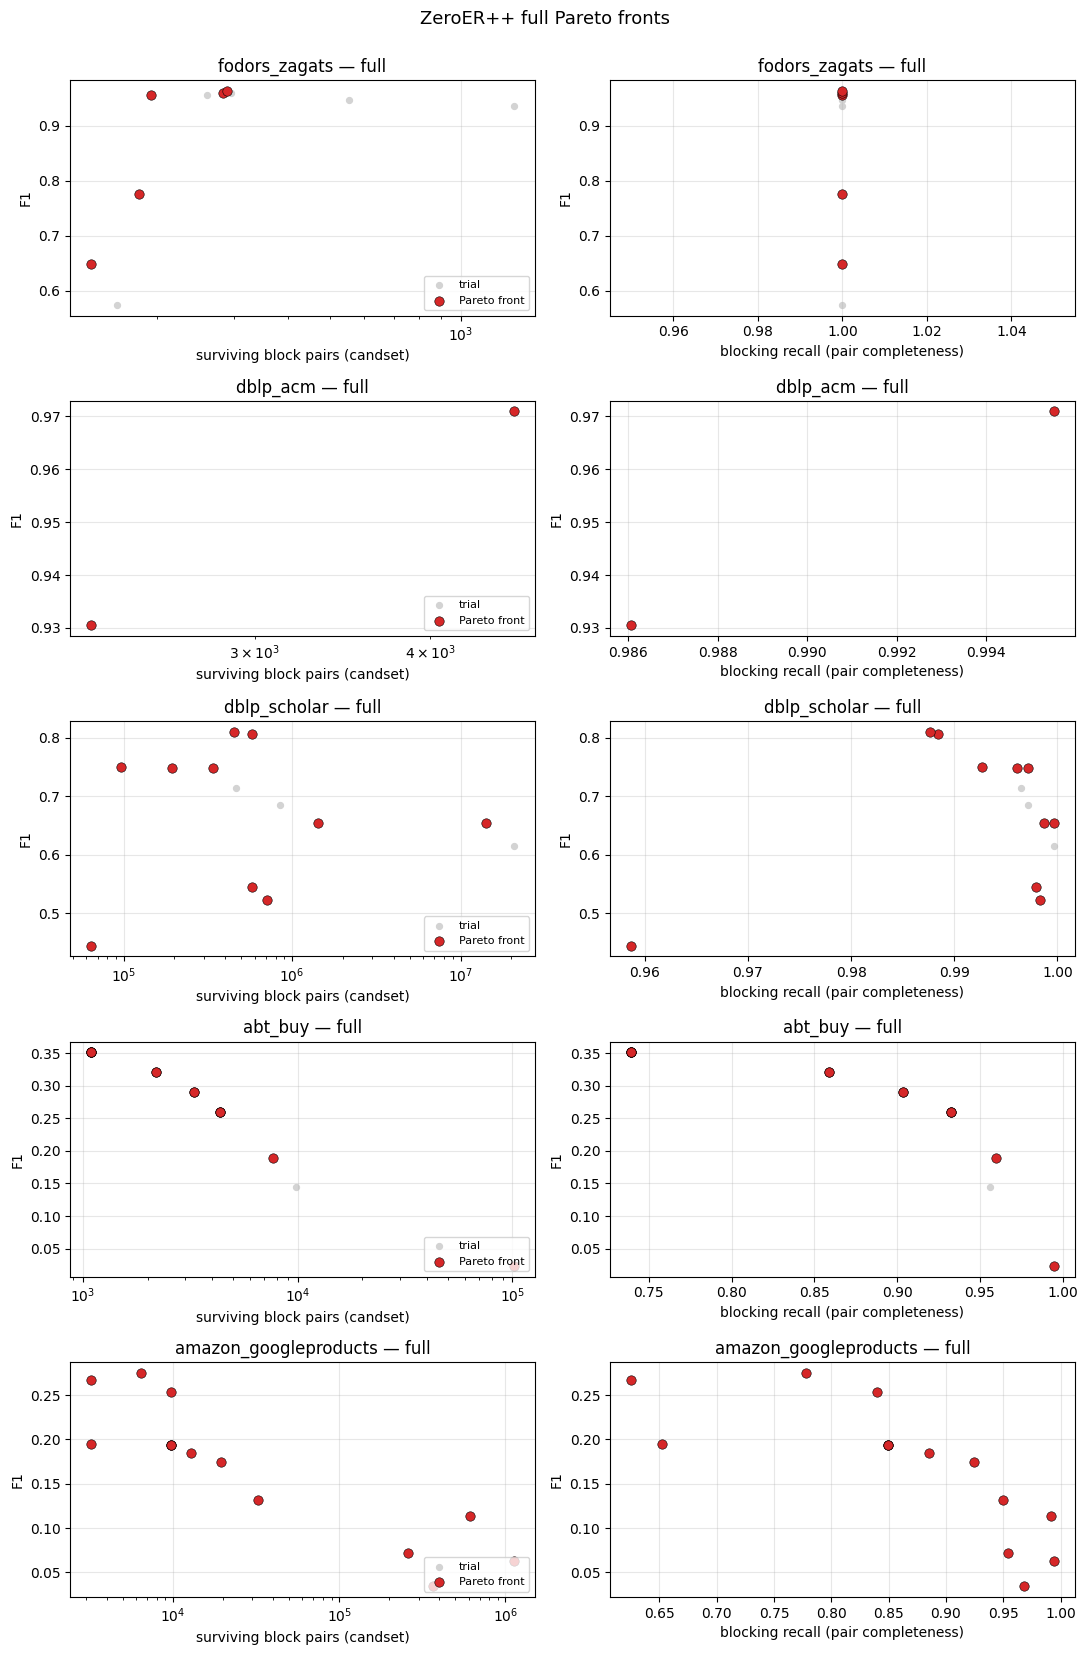

In [5]:
show_results()

In [6]:
import sqlite3

conn = sqlite3.connect("./outputs/optuna.db")
cur = conn.cursor()

cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cur.fetchall())

[('studies',), ('version_info',), ('study_directions',), ('study_user_attributes',), ('study_system_attributes',), ('trials',), ('trial_user_attributes',), ('trial_system_attributes',), ('trial_params',), ('trial_values',), ('trial_intermediate_values',), ('trial_heartbeats',), ('alembic_version',)]


In [8]:
cur.execute("SELECT * FROM studies;")
print(cur.fetchall())

[(1, 'fodors_zagats'), (2, 'dblp_acm'), (3, 'dblp_scholar'), (4, 'abt_buy'), (5, 'amazon_googleproducts'), (6, 'fodors_zagats_full'), (7, 'dblp_acm_full'), (8, 'dblp_scholar_full'), (9, 'abt_buy_full'), (10, 'amazon_googleproducts_full')]
